In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

housing = fetch_california_housing(as_frame=True)

df = housing.frame

print(df.head())

X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


In [2]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_predictions)
lr_mse = mean_squared_error(y_test, lr_predictions)
lr_rmse = np.sqrt(lr_mse)
lr_r2 = r2_score(y_test, lr_predictions)

print("Linear Regression")
print("MAE :", lr_mae)
print("MSE :", lr_mse)
print("RMSE:", lr_rmse)
print("R2 Score:", lr_r2)

Linear Regression
MAE : 0.5332001304956555
MSE : 0.5558915986952442
RMSE: 0.7455813830127763
R2 Score: 0.575787706032451


In [4]:
from sklearn.svm import SVR

svr_model = SVR(kernel='rbf')

svr_model.fit(X_train_scaled, y_train)

svr_predictions = svr_model.predict(X_test_scaled)

svr_mae = mean_absolute_error(y_test, svr_predictions)
svr_mse = mean_squared_error(y_test, svr_predictions)
svr_rmse = np.sqrt(svr_mse)
svr_r2 = r2_score(y_test, svr_predictions)

print("Support Vector Regression")
print("MAE :", svr_mae)
print("MSE :", svr_mse)
print("RMSE:", svr_rmse)
print("R2 Score:", svr_r2)

Support Vector Regression
MAE : 0.39859907695205365
MSE : 0.35700403193386493
RMSE: 0.5974981438748282
R2 Score: 0.7275628923016774


In [5]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(random_state=42)

dt_model.fit(X_train, y_train)

dt_predictions = dt_model.predict(X_test)

dt_mae = mean_absolute_error(y_test, dt_predictions)
dt_mse = mean_squared_error(y_test, dt_predictions)
dt_rmse = np.sqrt(dt_mse)
dt_r2 = r2_score(y_test, dt_predictions)

print("Decision Tree Regression")
print("MAE :", dt_mae)
print("MSE :", dt_mse)
print("RMSE:", dt_rmse)
print("R2 Score:", dt_r2)

Decision Tree Regression
MAE : 0.45467918846899225
MSE : 0.495235205629094
RMSE: 0.7037294974840077
R2 Score: 0.622075845135081


In [6]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Support Vector Regression", "Decision Tree"],
    "MAE": [lr_mae, svr_mae, dt_mae],
    "MSE": [lr_mse, svr_mse, dt_mse],
    "RMSE": [lr_rmse, svr_rmse, dt_rmse],
    "R2 Score": [lr_r2, svr_r2, dt_r2]
})

print(results)

                       Model       MAE       MSE      RMSE  R2 Score
0          Linear Regression  0.533200  0.555892  0.745581  0.575788
1  Support Vector Regression  0.398599  0.357004  0.597498  0.727563
2              Decision Tree  0.454679  0.495235  0.703729  0.622076


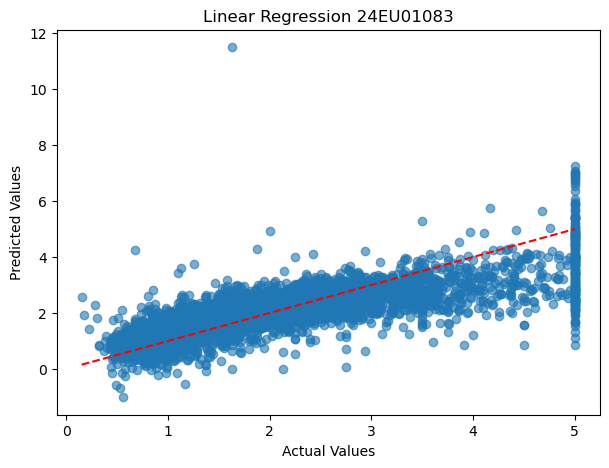

In [7]:
plt.figure(figsize=(7,5))

plt.scatter(y_test, lr_predictions, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.title("Linear Regression 24EU01083")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

plt.show()

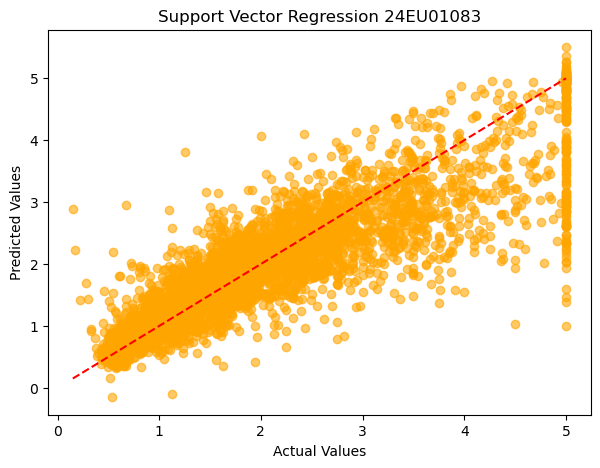

In [8]:
plt.figure(figsize=(7,5))

plt.scatter(y_test, svr_predictions, alpha=0.6, color='orange')

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.title("Support Vector Regression 24EU01083")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

plt.show()

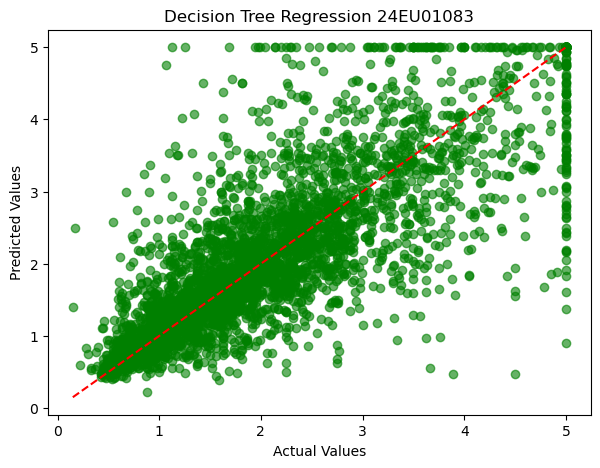

In [9]:
plt.figure(figsize=(7,5))

plt.scatter(y_test, dt_predictions, alpha=0.6, color='green')

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.title("Decision Tree Regression 24EU01083")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

plt.show()